# PHYS3116 Tutorial 4: Curve Fitting and Star Formation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks

## Worked Example: Linear Curve Fitting

In [ ]:
# Randomly Generate Data
gradient = 25
x = np.arange(0, 100, 1)
y = gradient * x + 1000 * np.random.rand(100)

df = pd.DataFrame({
    'x': x,
    'y': y,
})

In [ ]:
plt.plot(
    df['x'],
    df['y'],
    'x'
)

Linear Regression yields the following parameters:
- `slope`
- `intercept`
- `rvalue`
- `pvalue`
- `stderr`: standard error of slope
- `intercept_stderr`: standard error of intercept


High `rvalue` (magnitude between 0.7 and 0.1) indicates strong linear relationship.  
`pvalue < 5%` is considered strong evidence for a linear fit (i.e probability of getting such an extreme outcome is less than 5%)

In [ ]:
# Fit a linear curve
result = stats.linregress(x, y)
print(result)
print(f'Line has equation y = ({result.slope:.2f} +- {result.stderr:.2f}) * x + ({result.intercept:.2f} +- {result.intercept_stderr:.2f})')
print(f'Result has R-value of {result.rvalue:.2f} and p-value of {result.pvalue:.2e}')

In [ ]:
plt.plot(
    df['x'],
    df['y'],
    'x',
    label='Data'
)
# Adding LOB to graph
plt.plot(
    x, result.slope * x + result.intercept,
    label=f'y = {result.slope:.2f} * x + {result.slope:.2f}'
)
plt.legend()

## Worked Example: Star Formation Rate as a function of stellar mass and age.

In [ ]:
data = pd.read_csv('PHYS3116_Week4_Tutorial_Data.csv')
data = data[(data['alpha_re'] > -99) & (data['z_re'] > -99)]

In [ ]:
plt.scatter(
    data['mstar'],
    np.log(data['sfr_re']),
    c=np.log(data['age_re']),
    marker='.'
)
cbar = plt.colorbar()

plt.title(r'Star-Forming Rate vs Stellar Mass')
plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')
plt.ylabel(r'Star Formation ($\log M_\odot / yr$)')
cbar.set_label(r'Log of Age')

In [ ]:
plt.scatter(
    data['mstar'],
    np.log(data['sfr_re']),
    c=data['alpha_re'],
    marker='.'
)
cbar = plt.colorbar()

plt.title(r'Star-Forming Rate vs Stellar Mass')
plt.xlabel('Log of Stellar Mass ($\log M_\odot$)')
plt.ylabel(r'Star Formation ($\log M_\odot / yr$)')
cbar.set_label(r'$[\alpha / Fe]$')

# Exercises

## 1) Star Formation Rates + Linear Regression
#### a) Does morphology affect the star-formation rate? (Plot Star Formation rate vs stellar mass for ellipticals (Type = 0, 0.5) and Spirals (Type = 2,  2.5, 3)
#### b) Using `stats.linregress`, find star formation rate as a function of mass for spiral galaxies, i.e. find values `A` and `B` in `star formation rate = A log (stellar mass) + B`. Is the relationship strong?

Data for this weeks tutorial comes from SAMI:
- `sami_dr3.EmissionLine1compDR3`
    - `sfr_re`: Star formation rate in RE aperture 
- `sami_dr3.SSPAperturesDR3`
    - `alpha_re`: SSP alpha abundance within the RE aperture
    - `z_re`: SSP metallicity within the RE aperture
- `sami_dr3.VisualMorphologyDR3`
    - `type`: Morphological Type (0=E; 0.5=E/S0; 1=S0; 1.5=S0/Early-spiral; 2=Early-spiral; 2.5=Early/Late spiral; 3=Late spiral; 5=?; -9=no agreement)    
- `sami_dr3.InputCatClustersDR3` and `sami_dr3.InputCatGAMADR3`:
    - `mstar`: Logarithm of stellar mass

In [ ]:
data = pd.read_csv('PHYS3116_Week4_Tutorial_Data.csv')
data = data[(data['alpha_re'] > -99) & (data['z_re'] > -99)]
data = data.dropna(subset=['mstar', 'sfr_re'])

In [ ]:
# 1) a)

In [ ]:
# 1) b) 

## 2) Spectra 
#### a) Compute the red-shift of this particular galaxy given that the Balmer Alpha line is 6562.8 Angstrom in the rest frame. Identify any other relevant peaks. 
#### b) Transforming your graph in 2)a) from a redshifted wavelength scale to the rest frame wavelength scale.

Recall that:
$$
    z = \frac{\Delta \lambda}{\lambda_0}
$$

where $\lambda_0$ is rest frame wavelength and $\Delta \lambda = \lambda - \lambda_0$

Note for the data:
- Wavelength is in $Angstrom$
- Flux is in $10^{-20} Angstrom^-1 cm^-2 erg s^{-1}$

This link may be useful for identifying spectra [Galaxy Spectra](http://astronomy.nmsu.edu/nicole/teaching/ASTR505/lectures/lecture26/slide01.html)

In [2]:
mysterious_galaxy = pd.read_csv('mysterious_galaxy.csv')
mysterious_galaxy['flux'] = np.where(mysterious_galaxy['flux'] == 0, np.nan, mysterious_galaxy['flux'])

In [5]:
peaks, _ = find_peaks(mysterious_galaxy['flux'], prominence=10000)
halpha_wavelength = mysterious_galaxy['wavelength'][peaks].iloc[0]
halpha_flux = mysterious_galaxy['flux'][peaks].iloc[0]

In [6]:
halpha_wavelength

8472.5

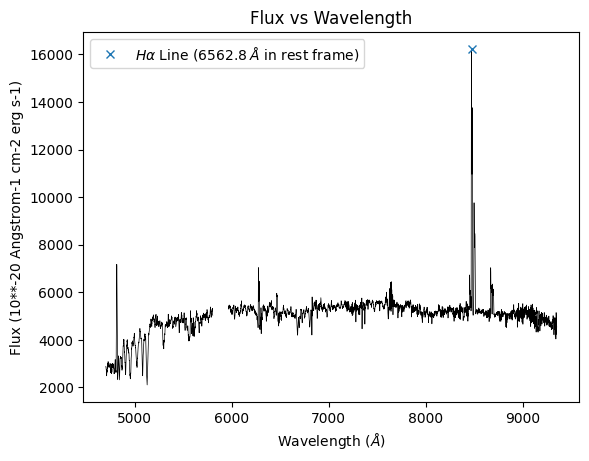

In [4]:
plt.plot(
    mysterious_galaxy['wavelength'],
    mysterious_galaxy['flux'],
    'k-',
    linewidth='0.5'
)

plt.plot(
    halpha_wavelength,
    halpha_flux,
    'x',
    label=r'$H\alpha$ Line ($6562.8 \; \AA$ in rest frame)'
)

plt.title('Flux vs Wavelength')
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('Flux (10**-20 Angstrom-1 cm-2 erg s-1)')
plt.legend()

In [ ]:
# 2) a)

In [ ]:
# 2) b)